# Route Choice Model Training Dataset 구축
> OTP K-best 경로 × 스마트카드 실제 통행 → OD별 선택 확률 데이터셋

**구조**: 각 행 = 1개 OD × 1개 대안경로
- **21개 경로 피처**: 시간, 거리, 환승, 요금, 모드 등
- **choice_prob (y)**: 해당 대안의 선택 확률 (= 매칭된 SC trip 수 / 전체 SC trip 수)
- 신규 수단(GTX 등) 도입 시, 경로 속성만 입력하면 선택 확률을 예측

In [14]:
import pandas as pd
import numpy as np
import json
import csv
import os
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import ijson

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

from module.route_features import (
    extract_itinerary_features, extract_trip_context, fix_missing_distances,
)
from module.similarity import (
    parse_otp_itinerary,
    parse_smartcard_trip,
    deduplicate_itineraries,
    compute_all_metrics,
    compute_composite_similarity,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# === 설정 ===
OTP_INPUT_CSV = '../data/otp/input/otp_od_input_over13.csv'
OTP_JSON_PATH = '../data/otp/output/similarity.json'
TCN_DIR = '../data/tcn'
OUTPUT_DIR = '../data/training_set'

# 매칭 파라미터
SIMILARITY_THRESHOLD = 0.6   # 매칭 임계값 (미만이면 skip)
MIN_CHOICE_SET_SIZE = 2      # 최소 대안 수 (미만이면 OD 제외)

# 테스트 / 전체 실행
MAX_ODS = 100  # None=전체, int=테스트용 OD 수 제한

# 체크포인트
CHECKPOINT_INTERVAL = 2000   # OD 단위

# GTFS (폴리라인 기반 공간 매칭)
USE_GTFS = False  # True: GTFS 기반 폴리라인 매칭 사용

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')
print(f'MAX_ODS: {MAX_ODS or "전체"}')

Output: ../data/training_set
MAX_ODS: 100


In [16]:
# === OTP 결과 로드 (ijson 스트리밍) + 거리 복원 + 중복 제거 ===

# 1. CSV에서 id → od_pair 매핑 생성
od_map = {}
with open(OTP_INPUT_CSV) as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        od_map[i] = row['od_pair']
print(f'CSV OD pairs: {len(od_map):,}')

# 2. JSON 스트리밍 (use_float=True로 Decimal 방지) + distance 복원
otp_results_raw = {}
loaded = 0

with open(OTP_JSON_PATH, 'rb') as f:
    for item in tqdm(ijson.items(f, 'item', use_float=True),
                     desc='OTP JSON 스트리밍', total=len(od_map)):
        item_id = item.get('id')
        itins = item.get('data', {}).get('plan', {}).get('itineraries', [])
        if not itins:
            continue

        od_pair = od_map.get(item_id)
        if od_pair is None:
            continue

        # distance=0인 transit leg → polyline에서 거리 복원
        for itin in itins:
            fix_missing_distances(itin)

        otp_results_raw[od_pair] = itins
        loaded += 1

        if MAX_ODS and loaded >= MAX_ODS:
            break

print(f'\nOTP 로드 완료: {loaded:,} ODs')
print(f'총 itineraries: {sum(len(v) for v in otp_results_raw.values()):,}')

# 3. 중복 제거 + 최소 대안 수 필터
otp_results = {}
for od_pair, itins in tqdm(otp_results_raw.items(), desc='중복 제거'):
    deduped = deduplicate_itineraries(itins)
    if len(deduped) >= MIN_CHOICE_SET_SIZE:
        otp_results[od_pair] = deduped

print(f'\n중복 제거 후 (≥{MIN_CHOICE_SET_SIZE}개 대안):')
print(f'  OD pairs: {len(otp_results):,}')
if otp_results:
    print(f'  평균 경로 수: {np.mean([len(v) for v in otp_results.values()]):.1f}')
    route_counts = [len(v) for v in otp_results.values()]
    print(f'  경로 수 분포:')
    for n in sorted(set(route_counts)):
        cnt = route_counts.count(n)
        print(f'    {n}개: {cnt:,} ODs ({cnt/len(otp_results)*100:.1f}%)')

# 4. 거리 복원 검증 (첫 OD 샘플)
sample_od = next(iter(otp_results))
sample_itin = otp_results[sample_od][0]
print(f'\n--- 거리 복원 검증: {sample_od} ---')
for leg in sample_itin.get('legs', []):
    mode = leg.get('mode')
    dist = leg.get('distance', 0)
    dur = leg.get('duration', 0)
    route = (leg.get('route') or {}).get('shortName', '-')
    print(f'  {mode:8s} route={route:8s} dist={dist:>10.1f}m  dur={dur:>6.0f}s')

CSV OD pairs: 774,895


OTP JSON 스트리밍:   0%|          | 99/774895 [00:00<40:32, 318.47it/s]



OTP 로드 완료: 100 ODs
총 itineraries: 493


중복 제거: 100%|██████████| 100/100 [00:00<00:00, 25000.32it/s]


중복 제거 후 (≥2개 대안):
  OD pairs: 89
  평균 경로 수: 3.3
  경로 수 분포:
    2개: 24 ODs (27.0%)
    3개: 27 ODs (30.3%)
    4개: 25 ODs (28.1%)
    5개: 13 ODs (14.6%)

--- 거리 복원 검증: 10003_10661 ---
  WALK     route=-        dist=       8.4m  dur=     7s
  BUS      route=5531     dist=   13778.8m  dur=  3029s
  WALK     route=-        dist=       1.2m  dur=     1s


In [17]:
# === TCN 날짜 확인 (메모리 절약: 실제 로드는 Cell 6에서 날짜별로) ===
TCN_DATES = sorted([d for d in os.listdir(TCN_DIR)
                    if os.path.isdir(os.path.join(TCN_DIR, d))])
print(f'TCN 날짜: {TCN_DATES} ({len(TCN_DATES)}일)')

# 파일 수 확인
for date in TCN_DATES:
    files = glob.glob(os.path.join(TCN_DIR, date, '*.parquet'))
    print(f'  {date}: {len(files)} files')

TCN 날짜: ['20250217', '20250218', '20250219', '20250220', '20250221', '20250222', '20250223'] (7일)
  20250217: 1 files
  20250218: 1 files
  20250219: 1 files
  20250220: 1 files
  20250221: 1 files
  20250222: 1 files
  20250223: 1 files


In [18]:
# === GTFS 룩업 (optional) ===
gtfs_lookup = None
if USE_GTFS:
    try:
        from module.gtfs_lookup import GTFSRouteLookup
        GTFS_DIR = '../data/gtfs/a1'
        gtfs_lookup = GTFSRouteLookup(GTFS_DIR)
        print(f'GTFS 룩업 로드 완료: {len(gtfs_lookup.route_stops)} 노선')
    except Exception as e:
        print(f'GTFS 로드 실패 (skip): {e}')
else:
    print('GTFS 미사용 (USE_GTFS=False)')

GTFS 미사용 (USE_GTFS=False)


In [ ]:
# === 메인 처리: 날짜별 TCN 로드 → 매칭 → 해제 ===
import gc

CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'training_checkpoint.parquet')

# legGeometry 덕분에 GTFS 없이도 spatial 비교 가능
if USE_GTFS:
    sim_weights = None  # 기본값: spatial 0.50
else:
    # legGeometry 기반 spatial 활용 (GTFS 없이도 OTP polyline → SC 좌표 근접도)
    sim_weights = {
        'mode': 0.14, 'sequence': 0.21, 'time': 0.14,
        'route': 0.21, 'spatial': 0.30,
    }
    print(f'Non-GTFS 가중치 (legGeometry 기반): {sim_weights}')

# OTP 피처 사전 캐시 (OD별 1회, 날짜와 무관)
otp_od_set = set(otp_results.keys())
print(f'OTP 피처 사전 계산: {len(otp_od_set):,} ODs ...')
otp_cache = {}
for od_pair, itins in tqdm(otp_results.items(), desc='OTP 피처 캐시'):
    otp_cache[od_pair] = {
        'alt_features': [extract_itinerary_features(itin) for itin in itins],
        'otp_parsed': [parse_otp_itinerary(itin, gtfs_lookup=gtfs_lookup) for itin in itins],
        'n_alts': len(itins),
    }

# 이어하기 지원
processed_trips = set()
all_rows = []
if os.path.exists(CHECKPOINT_PATH):
    ckpt_df = pd.read_parquet(CHECKPOINT_PATH)
    processed_trips = set(ckpt_df['trip_id'].unique())
    all_rows = ckpt_df.to_dict('records')
    print(f'체크포인트 로드: {len(processed_trips):,} trips, {len(all_rows):,}행')
else:
    print('체크포인트 없음, 처음부터 시작')

trip_counter = len(processed_trips)
skip_count = 0
match_count = 0
total_sc = 0

# === 날짜별 루프 ===
for date in TCN_DATES:
    print(f'\n--- {date} 처리 중 ---')

    # 1. 해당 날짜 TCN 로드
    tcn_list = []
    for pf in glob.glob(os.path.join(TCN_DIR, date, '*.parquet')):
        df = pd.read_parquet(pf)
        tcn_list.append(df)
    if not tcn_list:
        print(f'  파일 없음, skip')
        continue

    tcn_day = pd.concat(tcn_list, ignore_index=True)
    del tcn_list
    tcn_day['date'] = date

    # 2. OTP OD와 매칭되는 것만 필터링
    tcn_filtered = tcn_day[tcn_day['od_pair'].isin(otp_od_set)]
    n_day_total = len(tcn_day)
    n_day_matched = len(tcn_filtered)
    del tcn_day

    if n_day_matched == 0:
        print(f'  {date}: {n_day_total:,}건 중 매칭 대상 0건, skip')
        gc.collect()
        continue

    print(f'  {date}: {n_day_total:,}건 → 매칭 대상 {n_day_matched:,}건')
    total_sc += n_day_matched

    # 3. OD별 그룹화 + 매칭
    tcn_grouped = dict(list(tcn_filtered.groupby('od_pair')))
    del tcn_filtered

    day_match = 0
    day_skip = 0

    for od_pair, sc_trips in tcn_grouped.items():
        cache = otp_cache.get(od_pair)
        if cache is None:
            continue

        alt_features = cache['alt_features']
        otp_parsed_list = cache['otp_parsed']
        n_alts = cache['n_alts']

        for _, sc_row in sc_trips.iterrows():
            sc_parsed = parse_smartcard_trip(sc_row, gtfs_lookup=gtfs_lookup)

            scores = []
            for idx, otp_p in enumerate(otp_parsed_list):
                metrics = compute_all_metrics(otp_p, sc_parsed)
                score_result = compute_composite_similarity(metrics, weights=sim_weights)
                scores.append({'idx': idx, **score_result})

            best = max(scores, key=lambda x: x['composite'])
            if best['composite'] < SIMILARITY_THRESHOLD:
                day_skip += 1
                continue

            day_match += 1
            context = extract_trip_context(sc_row)
            trip_id = f'{od_pair}_{date}_{trip_counter}'
            trip_counter += 1

            for s in scores:
                alt_idx = s['idx']
                all_rows.append({
                    'trip_id': trip_id,
                    'od_pair': od_pair,
                    'alt_idx': alt_idx,
                    'choice_set_size': n_alts,
                    **alt_features[alt_idx],
                    **context,
                    'chosen': int(alt_idx == best['idx']),
                    'sim_composite': round(s['composite'], 4),
                    'sim_mode': round(s['mode_score'], 4),
                    'sim_sequence': round(s['sequence_score'], 4),
                    'sim_time': round(s['time_score'], 4),
                    'sim_route': round(s['route_score'], 4),
                    'sim_spatial': round(s['spatial_score'], 4),
                })

    match_count += day_match
    skip_count += day_skip
    print(f'  {date} 완료: 매칭={day_match:,}, skip={day_skip:,}')

    # 4. 메모리 해제
    del tcn_grouped
    gc.collect()

    # 5. 날짜별 체크포인트
    pd.DataFrame(all_rows).to_parquet(CHECKPOINT_PATH, index=False)
    print(f'  체크포인트 저장: {len(all_rows):,}행')

# 최종 DataFrame
training_df = pd.DataFrame(all_rows)
del otp_cache
gc.collect()

print(f'\n=== 전체 완료 ===')
print(f'  총 SC 대상: {total_sc:,}건')
print(f'  매칭 성공: {match_count:,}건')
print(f'  매칭 실패: {skip_count:,}건')
total = match_count + skip_count
if total > 0:
    print(f'  매칭률: {match_count/total*100:.1f}%')
print(f'  총 행 수: {len(training_df):,}')
print(f'  선택상황(trips): {training_df["trip_id"].nunique():,}')
print(f'  OD pairs: {training_df["od_pair"].nunique():,}')

In [23]:
training_df

,trip_id,od_pair,alt_idx,choice_set_size,total_duration,in_vehicle_time,walk_time,wait_time,access_time,egress_time,...,departure_dow,is_peak,sc_transport_category,chosen,sim_composite,sim_mode,sim_sequence,sim_time,sim_route,sim_spatial
0,10003_10661_20250217_0,10003_10661,0,3,3087.0,3029.0,8.0,50.0,7.0,1.0,...,0,0,bus_only,1,0.9847,1.0,1.0000,0.9237,1.0000,0.0
1,10003_10661_20250217_0,10003_10661,1,3,1868.0,1202.0,433.0,233.0,272.0,1.0,...,0,0,bus_only,0,0.3618,0.5,0.5000,0.5589,0.0000,0.0
2,10003_10661_20250217_0,10003_10661,2,3,1949.0,1202.0,433.0,314.0,272.0,1.0,...,0,0,bus_only,0,0.3666,0.5,0.5000,0.5832,0.0000,0.0
3,10003_10700_20250217_1,10003_10700,0,3,2842.0,2790.0,14.0,38.0,7.0,7.0,...,0,0,bus_only,1,0.7485,1.0,0.6667,0.9923,0.5000,0.0
4,10003_10700_20250217_1,10003_10700,1,3,1673.0,986.0,439.0,248.0,272.0,7.0,...,0,0,bus_only,0,0.4668,0.5,0.5000,0.5841,0.3333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12462,10018_152_20250223_3952,10018_152,3,4,1600.0,1105.0,296.0,199.0,6.0,38.0,...,0,0,bus+train,1,0.6182,1.0,0.7500,0.9663,0.0000,0.0
12463,10018_152_20250223_3953,10018_152,0,4,1739.0,1137.0,562.0,40.0,279.0,283.0,...,0,0,bus+train,0,0.2778,0.5,0.0000,0.8890,0.0000,0.0
12464,10018_152_20250223_3953,10018_152,1,4,1637.0,1142.0,455.0,40.0,279.0,176.0,...,0,0,bus+train,0,0.2889,0.5,0.0000,0.9444,0.0000,0.0
12465,10018_152_20250223_3953,10018_152,2,4,1456.0,1110.0,105.0,241.0,6.0,38.0,...,0,0,bus+train,0,0.6134,1.0,0.7500,0.9418,0.0000,0.0


In [20]:
# === OD 단위 집계: choice_prob 계산 ===
print('=== OD 단위 집계 ===\n')

# 경로 피처 (OD × alt별 동일)
route_features = [
    'total_duration', 'in_vehicle_time', 'walk_time', 'wait_time',
    'access_time', 'egress_time', 'transfer_walk_time',
    'walk_distance', 'total_distance', 'bus_distance',
    'subway_distance', 'gtx_distance',
    'num_transfers', 'num_legs', 'fare', 'generalized_cost',
    'transport_category', 'has_bus', 'has_train', 'has_gtx', 'main_route',
]

# 1. OD × alt별 경로 피처 (고정값 → first)
od_alt_features = (
    training_df
    .groupby(['od_pair', 'alt_idx', 'choice_set_size'])
    [route_features]
    .first()
    .reset_index()
)

# 2. OD × alt별 chosen 집계
chosen_counts = (
    training_df[training_df['chosen'] == 1]
    .groupby(['od_pair', 'alt_idx'])
    .size()
    .reset_index(name='n_matched')
)

# 3. OD별 전체 매칭 trip 수
total_trips = (
    training_df
    .groupby('od_pair')['trip_id']
    .nunique()
    .reset_index(name='n_total')
)

# 4. OD별 od_distance (고정값)
od_dist = (
    training_df
    .groupby('od_pair')['od_distance']
    .first()
    .reset_index()
)

# 5. 병합
agg_df = od_alt_features.merge(chosen_counts, on=['od_pair', 'alt_idx'], how='left')
agg_df = agg_df.merge(total_trips, on='od_pair', how='left')
agg_df = agg_df.merge(od_dist, on='od_pair', how='left')
agg_df['n_matched'] = agg_df['n_matched'].fillna(0).astype(int)

# 6. choice_prob 계산 (y값)
agg_df['choice_prob'] = agg_df['n_matched'] / agg_df['n_total']

# 7. 평균 유사도 (검증용) — chosen=1인 trip들의 평균 유사도
sim_cols = ['sim_composite', 'sim_mode', 'sim_sequence', 'sim_time', 'sim_route']
avg_sim = (
    training_df[training_df['chosen'] == 1]
    .groupby(['od_pair', 'alt_idx'])
    [sim_cols]
    .mean()
    .reset_index()
)
agg_df = agg_df.merge(avg_sim, on=['od_pair', 'alt_idx'], how='left')
for col in sim_cols:
    agg_df[col] = agg_df[col].fillna(0)

# 정렬
agg_df = agg_df.sort_values(['od_pair', 'alt_idx']).reset_index(drop=True)

print(f'집계 결과:')
print(f'  행 수: {len(agg_df):,} (OD × alt)')
print(f'  OD pairs: {agg_df["od_pair"].nunique():,}')
print(f'  choice_set_size 분포:')
cs_dist = agg_df.groupby('od_pair')['alt_idx'].count().value_counts().sort_index()
for size, cnt in cs_dist.items():
    print(f'    {size}개 대안: {cnt:,} ODs')

# 검증: 각 OD의 choice_prob 합 = 1.0
prob_sums = agg_df.groupby('od_pair')['choice_prob'].sum()
not_one = prob_sums[(prob_sums - 1.0).abs() > 0.001]
print(f'\n검증: choice_prob 합 = 1.0: {"PASS" if len(not_one) == 0 else "FAIL"}')
if len(not_one) > 0:
    print(f'  위반 OD: {len(not_one)}')
    print(f'  합계 분포: min={prob_sums.min():.4f} max={prob_sums.max():.4f}')

# 샘플 출력
print(f'\n=== 샘플 (첫 OD) ===')
sample_od = agg_df['od_pair'].iloc[0]
sample = agg_df[agg_df['od_pair'] == sample_od][
    ['od_pair', 'alt_idx', 'choice_prob', 'n_matched', 'n_total',
     'total_duration', 'fare', 'num_transfers', 'transport_category']
]
print(sample.to_string(index=False))

=== OD 단위 집계 ===

집계 결과:
  행 수: 291 (OD × alt)
  OD pairs: 88
  choice_set_size 분포:
    2개 대안: 24 ODs
    3개 대안: 26 ODs
    4개 대안: 25 ODs
    5개 대안: 13 ODs

검증: choice_prob 합 = 1.0: PASS

=== 샘플 (첫 OD) ===
    od_pair  alt_idx  choice_prob  n_matched  n_total  total_duration  fare  num_transfers transport_category
10003_10661        0          1.0         13       13          3087.0  1500              0           bus_only
10003_10661        1          0.0          0       13          1868.0  1550              1          bus+train
10003_10661        2          0.0          0       13          1949.0  1550              1          bus+train


=== 수치 피처 통계 ===
       total_duration  in_vehicle_time  walk_time  wait_time  access_time  egress_time  transfer_walk_time  walk_distance  total_distance  bus_distance  subway_distance  gtx_distance  num_transfers  num_legs      fare  generalized_cost  od_distance  choice_prob
count         291.000          291.000    291.000    291.000      291.000      291.000             291.000        291.000         291.000       291.000          291.000         291.0        291.000   291.000   291.000           291.000      291.000      291.000
mean          932.247          666.361    145.478    120.419       41.821       63.598              40.058        174.573        4689.301      3688.238          826.490           0.0          0.447     1.447  1507.045        102793.471     3710.474        0.302
std           483.346          425.514    180.512    104.928       87.438      119.311              88.534        216.614        2938.617      2516.945         2309.846           0.0          0.563

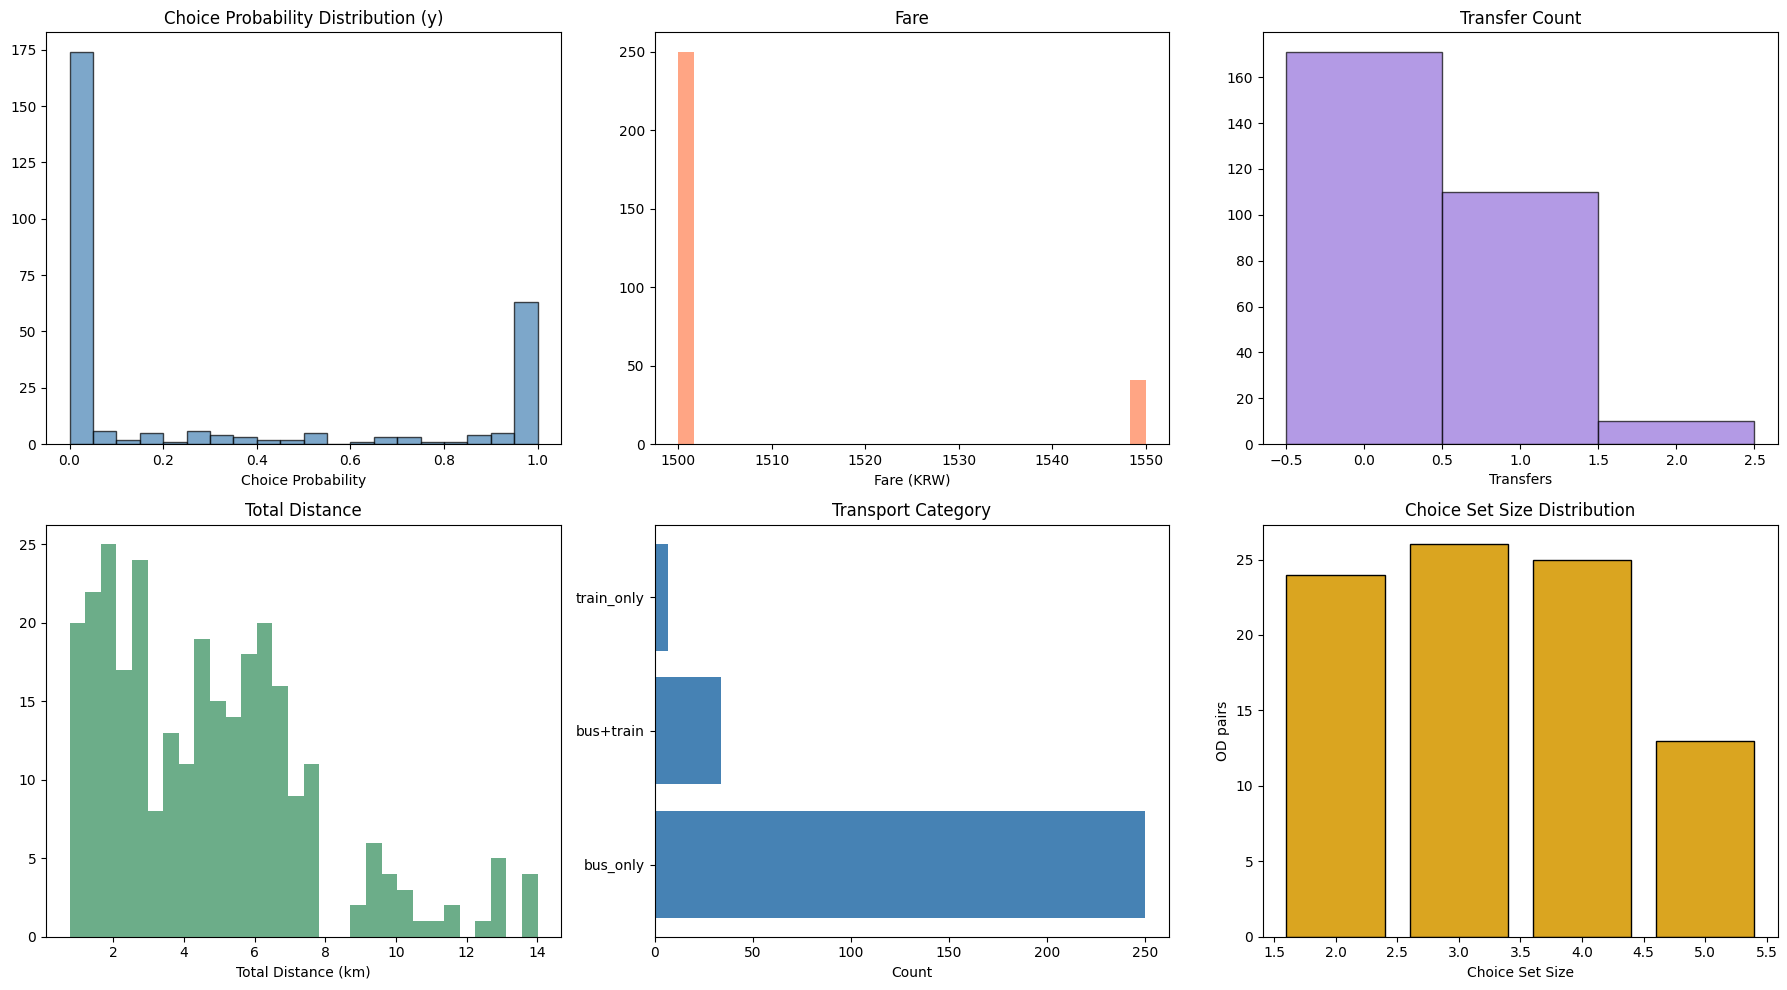

In [21]:
# === 피처 통계 + 시각화 ===
numeric_features = [
    'total_duration', 'in_vehicle_time', 'walk_time', 'wait_time',
    'access_time', 'egress_time', 'transfer_walk_time',
    'walk_distance', 'total_distance', 'bus_distance',
    'subway_distance', 'gtx_distance',
    'num_transfers', 'num_legs', 'fare', 'generalized_cost',
    'od_distance', 'choice_prob',
]

print('=== 수치 피처 통계 ===')
print(agg_df[numeric_features].describe().round(3).to_string())

print(f'\n=== transport_category 분포 ===')
print(agg_df['transport_category'].value_counts().to_string())

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(agg_df['choice_prob'], bins=20, alpha=0.7, color='steelblue',
                edgecolor='black')
axes[0, 0].set_xlabel('Choice Probability')
axes[0, 0].set_title('Choice Probability Distribution (y)')

axes[0, 1].hist(agg_df['fare'], bins=30, alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Fare (KRW)')
axes[0, 1].set_title('Fare')

axes[0, 2].hist(agg_df['num_transfers'],
                bins=range(0, agg_df['num_transfers'].max() + 2),
                alpha=0.7, color='mediumpurple', edgecolor='black', align='left')
axes[0, 2].set_xlabel('Transfers')
axes[0, 2].set_title('Transfer Count')

axes[1, 0].hist(agg_df['total_distance'] / 1000, bins=30, alpha=0.7, color='seagreen')
axes[1, 0].set_xlabel('Total Distance (km)')
axes[1, 0].set_title('Total Distance')

cat_counts = agg_df['transport_category'].value_counts()
axes[1, 1].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Transport Category')

cs_dist_plot = agg_df.groupby('od_pair')['alt_idx'].count().value_counts().sort_index()
axes[1, 2].bar(cs_dist_plot.index, cs_dist_plot.values,
               color='goldenrod', edgecolor='black')
axes[1, 2].set_xlabel('Choice Set Size')
axes[1, 2].set_ylabel('OD pairs')
axes[1, 2].set_title('Choice Set Size Distribution')

plt.tight_layout()
plt.show()

=== choice_prob과 피처 상관계수 ===
walk_time          -0.391416
num_transfers      -0.342796
wait_time          -0.307359
fare               -0.149563
generalized_cost   -0.114232
total_duration     -0.080107
total_distance     -0.003084
in_vehicle_time     0.150878


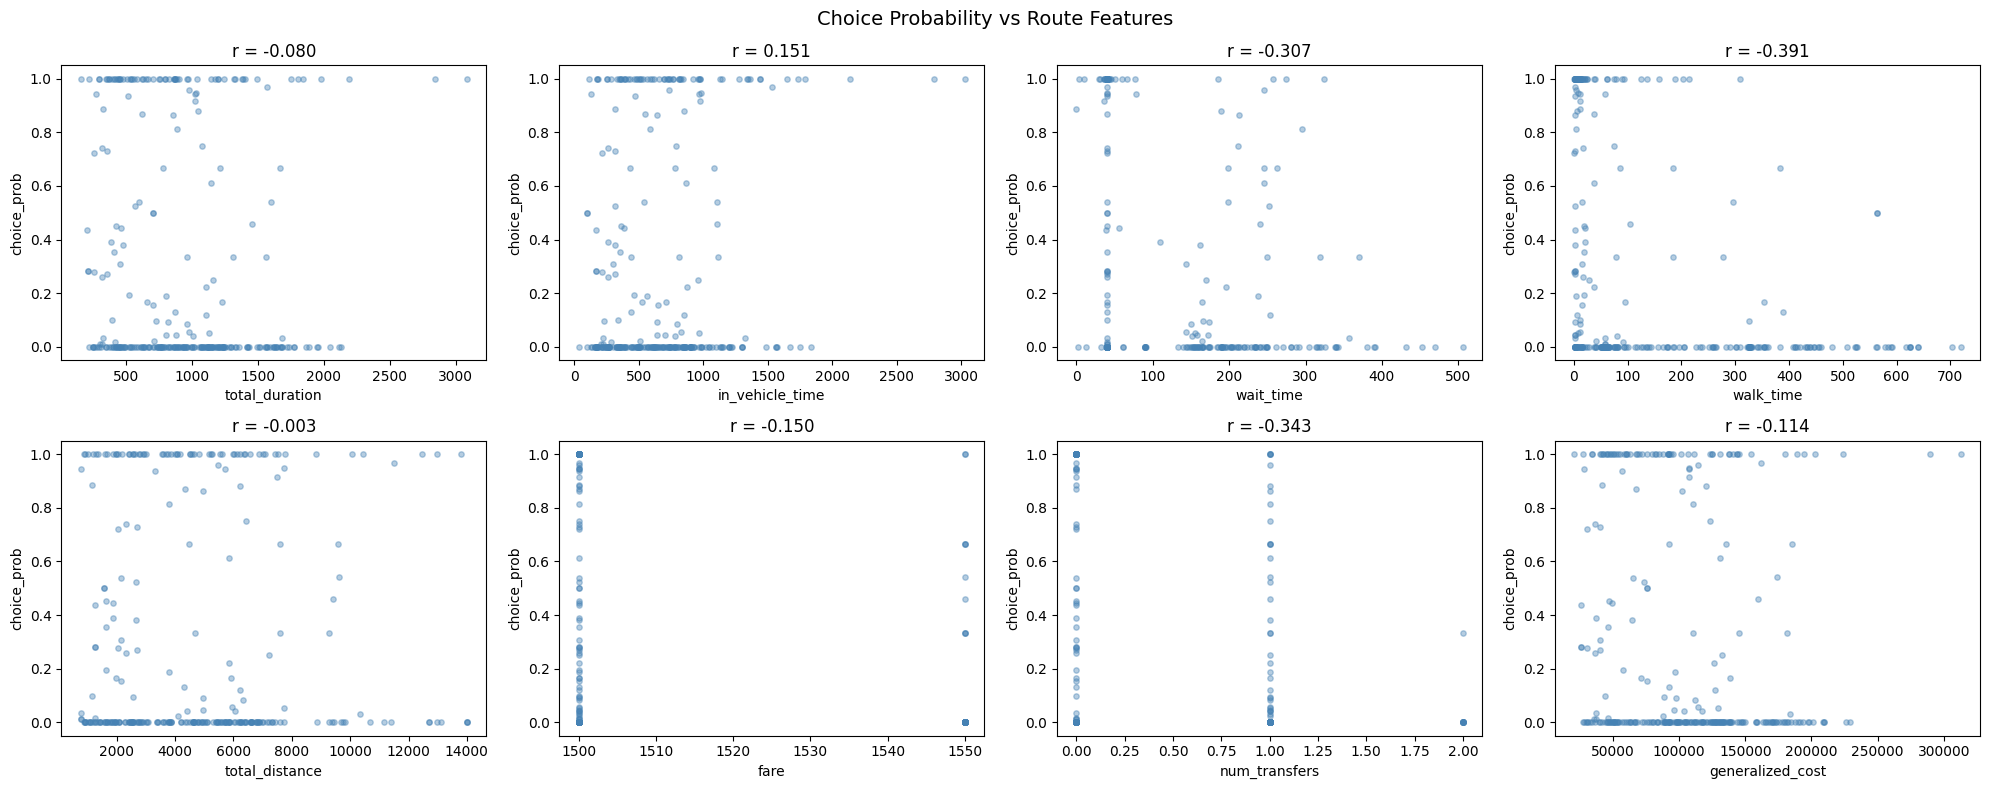


=== transport_category별 평균 choice_prob ===
                    avg_choice_prob  n_alternatives
transport_category                                 
bus_only                      0.328             250
bus+train                     0.176              34
train_only                    0.000               7


In [22]:
# === choice_prob vs 피처 상관관계 ===
compare_features = [
    'total_duration', 'in_vehicle_time', 'wait_time', 'walk_time',
    'total_distance', 'fare', 'num_transfers', 'generalized_cost',
]

print('=== choice_prob과 피처 상관계수 ===')
corr = agg_df[['choice_prob'] + compare_features].corr()['choice_prob'].drop('choice_prob')
print(corr.sort_values().to_string())

# 시각화: 피처별 choice_prob scatter
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, feat in enumerate(compare_features):
    ax = axes[idx]
    ax.scatter(agg_df[feat], agg_df['choice_prob'],
               alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('choice_prob')
    ax.set_title(f'r = {corr[feat]:.3f}')

plt.suptitle('Choice Probability vs Route Features', fontsize=14)
plt.tight_layout()
plt.show()

# transport_category별 평균 선택 확률
print(f'\n=== transport_category별 평균 choice_prob ===')
cat_prob = agg_df.groupby('transport_category')['choice_prob'].agg(['mean', 'count'])
cat_prob.columns = ['avg_choice_prob', 'n_alternatives']
print(cat_prob.sort_values('n_alternatives', ascending=False).round(3).to_string())

In [24]:
# === 최종 저장 ===
PARQUET_PATH = os.path.join(OUTPUT_DIR, 'route_choice_training.parquet')
CSV_PATH = os.path.join(OUTPUT_DIR, 'route_choice_training.csv')

# OD 단위 집계 데이터 저장 (메인 트레이닝셋)
agg_df.to_parquet(PARQUET_PATH, index=False)
agg_df.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')

# 개인 trip 단위 데이터도 보존 (검증/분석용)
INDIVIDUAL_PATH = os.path.join(OUTPUT_DIR, 'route_choice_individual.parquet')
training_df.to_parquet(INDIVIDUAL_PATH, index=False)

# 체크포인트 정리
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'training_checkpoint.parquet')
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print('체크포인트 삭제')

print(f'\n=== 저장 완료 ===')
print(f'  [메인] {PARQUET_PATH}')
print(f'    행 수: {len(agg_df):,} (OD × alt)')
print(f'    OD pairs: {agg_df["od_pair"].nunique():,}')
print(f'    컬럼 수: {len(agg_df.columns)}')
print(f'  [개인] {INDIVIDUAL_PATH}')
print(f'    행 수: {len(training_df):,} (trip × alt)')

print(f'\n=== 메인 트레이닝셋 컬럼 ===')
for col in agg_df.columns:
    print(f'  - {col}: {agg_df[col].dtype}')

체크포인트 삭제

=== 저장 완료 ===
  [메인] ../data/training_set\route_choice_training.parquet
    행 수: 291 (OD × alt)
    OD pairs: 88
    컬럼 수: 33
  [개인] ../data/training_set\route_choice_individual.parquet
    행 수: 12,467 (trip × alt)

=== 메인 트레이닝셋 컬럼 ===
  - od_pair: object
  - alt_idx: int64
  - choice_set_size: int64
  - total_duration: float64
  - in_vehicle_time: float64
  - walk_time: float64
  - wait_time: float64
  - access_time: float64
  - egress_time: float64
  - transfer_walk_time: float64
  - walk_distance: float64
  - total_distance: float64
  - bus_distance: float64
  - subway_distance: float64
  - gtx_distance: int64
  - num_transfers: int64
  - num_legs: int64
  - fare: int64
  - generalized_cost: float64
  - transport_category: object
  - has_bus: int64
  - has_train: int64
  - has_gtx: int64
  - main_route: object
  - n_matched: int32
  - n_total: int64
  - od_distance: float64
  - choice_prob: float64
  - sim_composite: float64
  - sim_mode: float64
  - sim_sequence: float64


In [25]:
agg_df

,od_pair,alt_idx,choice_set_size,total_duration,in_vehicle_time,walk_time,wait_time,access_time,egress_time,transfer_walk_time,...,main_route,n_matched,n_total,od_distance,choice_prob,sim_composite,sim_mode,sim_sequence,sim_time,sim_route
0,10003_10661,0,3,3087.0,3029.0,8.0,50.0,7.0,1.0,0.0,...,5531,13,13,13022.0,1.000000,0.984131,1.0,1.000000,0.920669,1.000000
1,10003_10661,1,3,1868.0,1202.0,433.0,233.0,272.0,1.0,160.0,...,1호선,0,13,13022.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2,10003_10661,2,3,1949.0,1202.0,433.0,314.0,272.0,1.0,160.0,...,1호선,0,13,13022.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
3,10003_10700,0,3,2842.0,2790.0,14.0,38.0,7.0,7.0,0.0,...,5531,14,14,11710.7,1.000000,0.974657,1.0,0.976193,0.962529,0.964286
4,10003_10700,1,3,1673.0,986.0,439.0,248.0,272.0,7.0,160.0,...,1호선,0,14,11710.7,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,10018_150,4,5,1314.0,810.0,185.0,319.0,6.0,118.0,61.0,...,1호선,4,12,6108.7,0.333333,0.686000,1.0,0.750000,0.929925,0.249975
287,10018_152,0,4,1739.0,1137.0,562.0,40.0,279.0,283.0,0.0,...,506,0,24,7984.9,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
288,10018_152,1,4,1637.0,1142.0,455.0,40.0,279.0,176.0,0.0,...,501,0,24,7984.9,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
289,10018_152,2,4,1456.0,1110.0,105.0,241.0,6.0,38.0,61.0,...,1호선,11,24,7984.9,0.458333,0.651373,1.0,0.750000,0.915918,0.143927


In [26]:
training_df

,trip_id,od_pair,alt_idx,choice_set_size,total_duration,in_vehicle_time,walk_time,wait_time,access_time,egress_time,...,departure_dow,is_peak,sc_transport_category,chosen,sim_composite,sim_mode,sim_sequence,sim_time,sim_route,sim_spatial
0,10003_10661_20250217_0,10003_10661,0,3,3087.0,3029.0,8.0,50.0,7.0,1.0,...,0,0,bus_only,1,0.9847,1.0,1.0000,0.9237,1.0000,0.0
1,10003_10661_20250217_0,10003_10661,1,3,1868.0,1202.0,433.0,233.0,272.0,1.0,...,0,0,bus_only,0,0.3618,0.5,0.5000,0.5589,0.0000,0.0
2,10003_10661_20250217_0,10003_10661,2,3,1949.0,1202.0,433.0,314.0,272.0,1.0,...,0,0,bus_only,0,0.3666,0.5,0.5000,0.5832,0.0000,0.0
3,10003_10700_20250217_1,10003_10700,0,3,2842.0,2790.0,14.0,38.0,7.0,7.0,...,0,0,bus_only,1,0.7485,1.0,0.6667,0.9923,0.5000,0.0
4,10003_10700_20250217_1,10003_10700,1,3,1673.0,986.0,439.0,248.0,272.0,7.0,...,0,0,bus_only,0,0.4668,0.5,0.5000,0.5841,0.3333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12462,10018_152_20250223_3952,10018_152,3,4,1600.0,1105.0,296.0,199.0,6.0,38.0,...,0,0,bus+train,1,0.6182,1.0,0.7500,0.9663,0.0000,0.0
12463,10018_152_20250223_3953,10018_152,0,4,1739.0,1137.0,562.0,40.0,279.0,283.0,...,0,0,bus+train,0,0.2778,0.5,0.0000,0.8890,0.0000,0.0
12464,10018_152_20250223_3953,10018_152,1,4,1637.0,1142.0,455.0,40.0,279.0,176.0,...,0,0,bus+train,0,0.2889,0.5,0.0000,0.9444,0.0000,0.0
12465,10018_152_20250223_3953,10018_152,2,4,1456.0,1110.0,105.0,241.0,6.0,38.0,...,0,0,bus+train,0,0.6134,1.0,0.7500,0.9418,0.0000,0.0
